<a href="https://colab.research.google.com/github/MCSNicacio/Identificador-nota-o-cient-fica/blob/main/Atividade1_IA006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Atividade Prática 1 – Análise de Eletroencefalogramas

**(a) Descreva as principais características da base de dados (e.g., número de usuários, quantidade de sessões
(trials) etc.), bem como aspectos do protocolo experimental e da organização dos dados. Para isso, consulte
[Wang et al., 2017] e os arquivos de informações indicados no Readme.txt.**

O dataset corresponde às captações de EEG de 35 participantes saudáveis(17 mulheres com idade entre 17 e 34 anos) que tinham de focar su visão em un de 40 caracteres cintilantando em diferentes frequências (8-15Hz, com intervalo de 0,2 Hz). Para cada participante,6 blocos foram realizados, sendo cada bloco 40 ensaios correspondendo a 40 caracteres indicados em uma ordem aleatória. Cada ensaio começou com uma sinalização visual indicando o estímulo alvo, que aparecia por 0,5s na tela. As voluntárias tinham de deslocar seu foco até o alvo assim que possível durante a duração da sinalização. Após o offset da sinalização, todos os estímulos piscavam na tela durante 5s. Após isso, a tela ficava branca por 0.5s antes do início do próximo ensaio. Cada ensaio durou um total de 6s.

Os dados de EEG foram captadas com uma frequência de amostragem de 1000Hz e passaram por um filtro notch em 50 Hz a fim de retirar a interferência da rede elétrica.

Os dados de EEG foram segmentados em épocas de 6s e sub-amostrados para 250 Hz, correspondendo há 1500 pontos temporais por ensaio. Os dados referentes aos experimentos de cada voluntário foram armazendados em uma matriz quadri-dimensional do matlab de dimensões [64, 1500, 40, 6]. As dimensões indicam, respectivamente, "indíce do eletrodo", "pontos temporais", "indíce do alvo" e "indíce do bloco".

Abaixo segue o acesso aos dados da voluntária 5.

In [29]:
import scipy.io
mat = scipy.io.loadmat('/content/drive/MyDrive/data_IA006/S5.mat')

In [30]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'data'])

In [28]:
S5=mat['data']
print(S5.shape)

(64, 1500, 40, 6)


**(b) Considerando um usuário com experiência de uso de BCIs (S01 a S08), uma frequência de estímulo e uma
sessão de sua escolha, mostre os EEGs relacionados a três eletrodos diferentes – sendo pelo menos um deles
da região occipital –, considerando as seguintes visualizações:**

* Sinal no tempo;
* Magnitude da transformada discreta de Fourier do EEG;
* Densidade espectral de potência (PSD, do inglês power spectral density) do EEG obtida via periodograma
de Welch;
* Espectrograma do EEG.

**Discuta se a evocação está bem evidente ou não, além de avaliar se as frequências em que acontecem os picos
espectrais estão relacionadas à frequência do estímulo.**

In [43]:
''' freq_mat = scipy.io.loadmat('/content/drive/MyDrive/data_IA006/Freq_Phase.mat')
freq_mat.keys()
print(freq_mat["phases"])
print(freq_mat["freqs"]) '''

[[0.         1.57079633 3.14159265 4.71238898 0.         1.57079633
  3.14159265 4.71238898 1.57079633 3.14159265 4.71238898 0.
  1.57079633 3.14159265 4.71238898 0.         3.14159265 4.71238898
  0.         1.57079633 3.14159265 4.71238898 0.         1.57079633
  4.71238898 0.         1.57079633 3.14159265 4.71238898 0.
  1.57079633 3.14159265 0.         1.57079633 3.14159265 4.71238898
  0.         1.57079633 3.14159265 4.71238898]]
[[ 8.   9.  10.  11.  12.  13.  14.  15.   8.2  9.2 10.2 11.2 12.2 13.2
  14.2 15.2  8.4  9.4 10.4 11.4 12.4 13.4 14.4 15.4  8.6  9.6 10.6 11.6
  12.6 13.6 14.6 15.6  8.8  9.8 10.8 11.8 12.8 13.8 14.8 15.8]]


In [58]:
#atribuição de índices aos nomes de eletrodos, de acordo com o arquivo "64-channels.loc"
Oz= 62
PO8=59
PO7=53

print(S5[Oz,:,1,1])
print(len(S5[Oz,:,1,1]))


[-11.97312069  -9.17066383  -8.50582027 ...  -6.95609951 -12.66272545
 -10.59227943]
1500


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import welch, spectrogram

def eeg_plot(eeg,titulo):
  fs = 250  # Frequência de amostragem em Hz
  t = np.arange(0, 1500)
  # 1. Sinal no tempo
  plt.figure(figsize=(12, 10))

  plt.subplot(4, 1, 1)
  plt.plot(t, eeg)
  plt.title('Sinal no Tempo')
  plt.xlabel('Tempo [s]')
  plt.ylabel('Amplitude')

  # 2. Magnitude da FFT
  N = len(eeg)
  yf = np.fft.fft(eeg)
  xf = fftfreq(N, 1/fs)
    #2.1 Busca pela frequência que máximiza a magnitude da fft no intervalo entre 8 e 16 Hz

        # Considerar apenas a metade positiva do espectro
  xf_pos = xf[:N//2]
  yf_pos = np.abs(yf[:N//2])

        # Filtrar apenas as frequências entre 8 e 16 Hz
  mask = (xf_pos >= 8) & (xf_pos <= 16)
  xf_band = xf_pos[mask]
  yf_band = yf_pos[mask]

        # Encontrar a frequência com maior magnitude nesse intervalo
  max_index_band = np.argmax(yf_band)
  freq_max_band = xf_band[max_index_band]

  #plot da fft
  plt.subplot(4, 1, 2)
  plt.plot(xf[:N//8], np.abs(yf[:N//8]))
  plt.title('Magnitude da Transformada Discreta de Fourier')
  plt.xlabel('Frequência [Hz]')
  plt.ylabel('Magnitude')

  # 3. Densidade espectral de potência (Welch)
  f, Pxx = welch(eeg, fs, nperseg=256)

  plt.subplot(4, 1, 3)
  plt.semilogy(f, Pxx)
  plt.title('Densidade Espectral de Potência (Welch)')
  plt.xlabel('Frequência [Hz]')
  plt.ylabel('PSD [V**2/Hz]')

  # 4. Espectrograma
  f_spec, t_spec, Sxx = spectrogram(eeg, fs)

  plt.subplot(4, 1, 4)
  plt.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx), shading='gouraud')
  plt.title('Espectrograma')
  plt.xlabel('Tempo [s]')
  plt.ylabel('Frequência [Hz]')
  plt.colorbar(label='dB/Hz')
  # Título geral
  plt.suptitle(titulo, fontsize=16, fontweight='bold')

  # Ajuste do layout
  plt.tight_layout(rect=[0, 0, 1, 0.96])  # Espaço reservado para o título

  plt.show()
  print(f'Frequência com maior magnitude na FFT entre 8 e 16 Hz: {freq_max_band:.2f} Hz')



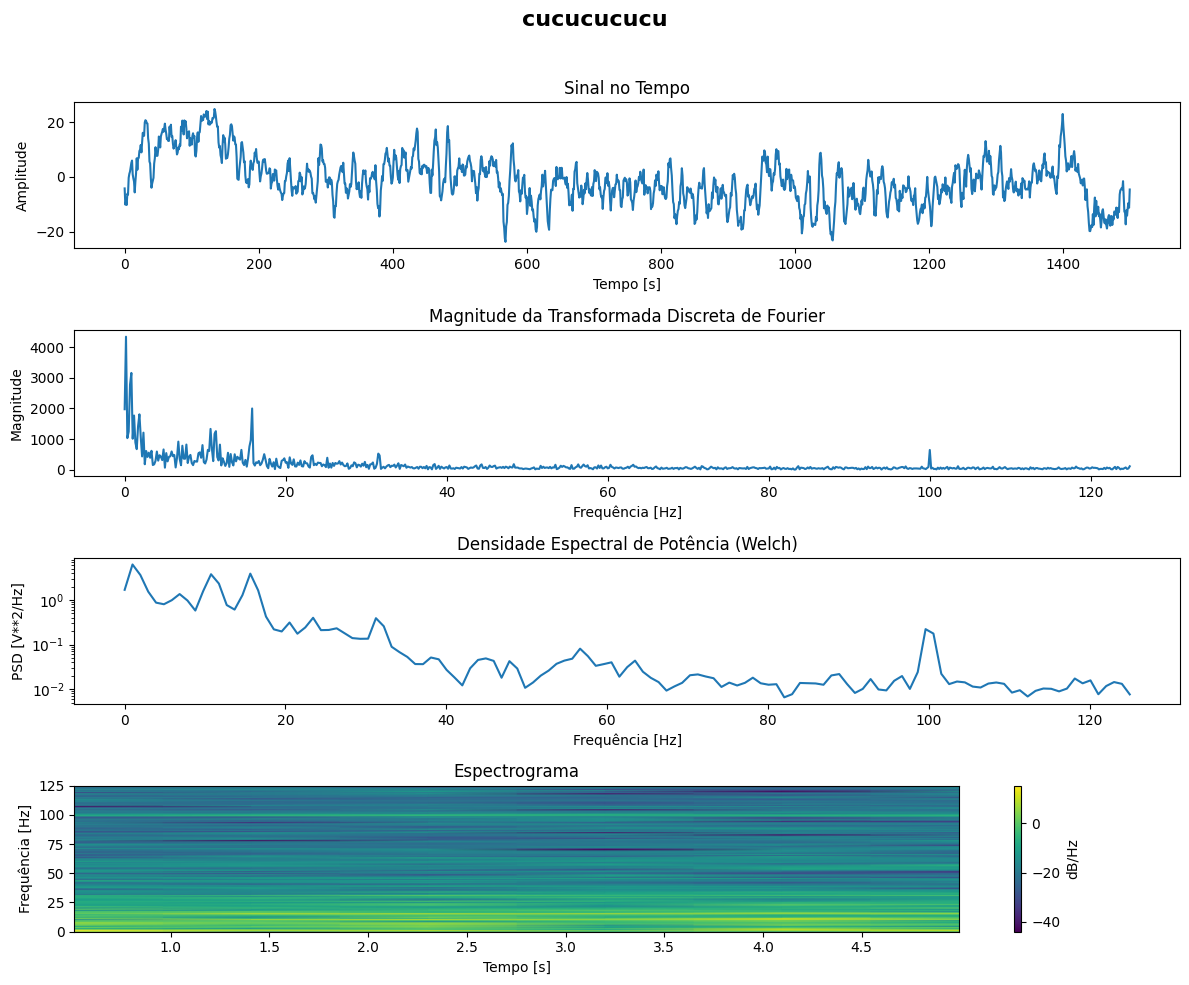

Frequência com maior magnitude na FFT entre 8 e 16 Hz: 15.83 Hz


In [96]:
eeg_plot(S5[Oz,:,39,1],"cucucucucu")